#### 1a: plt.hist中bins的使用，用于绘制条形图时确定左端点和右端点的位置，两个端点要分别覆盖最小值和最大值的区域，density=True:使面积为1；alpha：透明度
#### 1b：用均值之差表示两组值之间的绝对差异
#### 1c：用排列检验进行假设检验
把所有婴儿的体重数据混在一起，然后随机分成两组（组的大小和原来一样），计算这两组的均值差。这个过程重复很多次（比如1万次），每次都记录均值差，得到一组“在零假设成立时，均值差可能出现的情况”<br>
#### 1d：排列检验的实践，计算1w次随机后的均值差存入differences数组中
#### 1e：使用plot_distribution函数绘制differences的直方图
#### 1f：计算经验p值，表示在零假设下，观察到的检验统计量（observed_difference）大于或等于模拟的检验统计量的比例<br>
这里要用all_birthweights而不是birth['Birth Weight']，因为答案用的前者，使用后者得到的分布会略有不同导致答案错误<br>
**如果用np.random.choice要把replace设置为False，表示不放回的抽样**

In [74]:
# Initialize Otter
import otter
grader = otter.Notebook("hw01.ipynb")

In [75]:
import numpy as np
np.random.seed(42)
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

(array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <BarContainer object of 6 artists>)

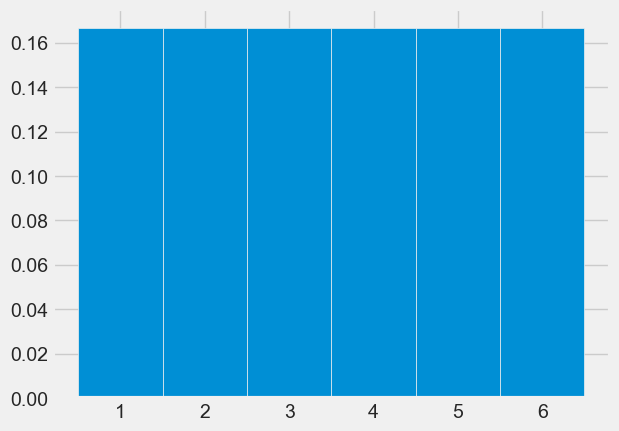

In [76]:
faces = range(1, 7)
# plt.hist(faces)
unit_bins = np.arange(0.5, 6.6)
plt.hist(faces, bins=unit_bins, ec='white', density=True)

### QUESTION 1a

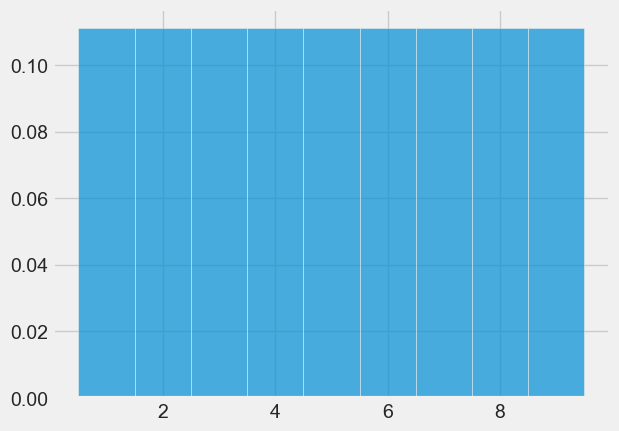

In [77]:
def plot_distribution(arr):
    # Define bins
    unit_bins = np.arange(round(min(arr)) - 0.5, round(max(arr)) + 0.6)
    # Plot the data arr using unit_bins, assign the plot to histplot
    histplot = plt.hist(arr, bins=unit_bins, ec='white', density=True, alpha=0.7)
    # print("Unit bins:", unit_bins)
    return histplot
faces = range(1, 10)
histplot = plot_distribution(faces)

In [78]:
grader.check("q1a")

q1a results: All test cases passed!

**这里的unit_bins是分箱的左端点和右端点；左端点应是最小值的整数部分-0.5（这样一个箱子的面积就是它的高度×1）；右端点应是最大值的整数部分＋1.5（因为只取整数部分是最大值箱子的中间部分）**<br>
这里最大值写+1也能通过<br>
原因：这两种写法都能通过测试，是因为`np.arange`生成的分箱右端点是开区间（不包含最后一个值），而你的数据是整数，分箱宽度为1。
- `+1`和`+1.5`都能保证最大值所在的箱子被覆盖，直方图每个条形都能正确统计到对应的整数值。
- 只要分箱能覆盖所有数据点且每个整数都落在一个箱子的中心，测试就能通过。
实际效果上，两者画出的直方图几乎一样。<br>
- 边界值是＋>0.5的值，因为分箱的右端点要能覆盖最大整数值的整个区间<br>

### Tutorial: Birthweights

回顾数据8，你可以使用排列检验执行[假设检验](https://inferentialthinking.com/chapters/12/1/AB_Testing.html)（第12.1章）。**在继续之前，我们强烈建议您阅读上述链接的Data8章节，这些章节是本练习的直接基础

在一项特殊的医学研究中，从一家大型医院系统中获得了新生儿样本。我们将把数据当作一个简单的随机样本来处理，尽管抽样是分多个阶段进行的。Deborah Nolan和Terry Speed在[Stat Labs]（https://www.stat.berkeley.edu/~statlabs/）中讨论了更大的数据集。

这项研究的目的之一是了解母亲吸烟是否与出生体重有关。**运行下面的单元格**，它将‘ nonsmoker_birth ’分配给不吸烟母亲的婴儿出生体重列表（其中有715个），并将‘ smoker_birth ’分配给吸烟母亲的婴儿出生体重列表（其中有459个）。

In [79]:
# Just run this cell. You will learn these functions soon!

import pandas as pd
births_df = pd.read_csv("births.csv")

nonsmoker_births = births_df[~births_df['Maternal Smoker']]['Birth Weight'].values
print(len(nonsmoker_births))

smoker_births = births_df[births_df['Maternal Smoker']]['Birth Weight'].values
print(len(smoker_births))

715
459


查看吸烟/不吸烟母亲的婴儿的体重的分布

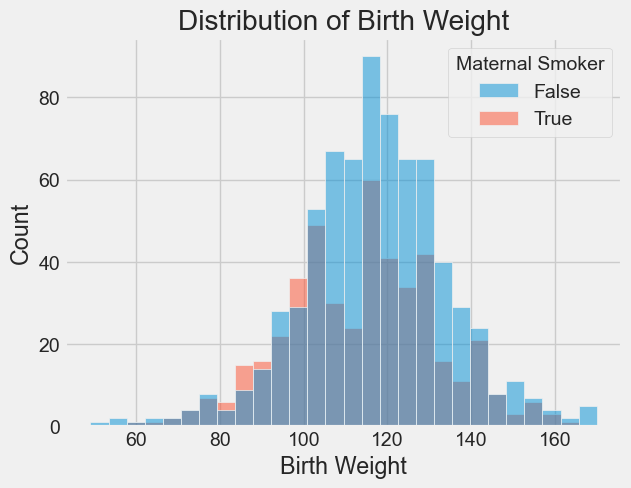

In [80]:
import seaborn as sns
sns.histplot(births_df, x="Birth Weight", hue="Maternal Smoker");
plt.title("Distribution of Birth Weight");

### Question 1b

假设我们选择一个合理的检验统计量作为两组（即不吸烟母亲的婴儿和吸烟母亲的婴儿）平均出生体重之间的绝对差异。

在下面的单元格中，给定“非吸烟者”和“吸烟者”的原始样本，将“观察到的检验统计量”赋值为“观察到的差异”。

即之前获取的nonsmoker_births的均值减去smoker_births的均值

In [81]:
observed_difference = nonsmoker_births.mean() - smoker_births.mean()
observed_difference

3.2661425720249184

In [82]:
grader.check("q1b")

q1b results: All test cases passed!

### Question 1c
假设我们想知道“母亲是否吸烟”会不会影响新生儿的体重。<br/>
零假设（H0）：母亲是否吸烟，对婴儿出生体重没有影响。也就是说，两组婴儿（吸烟母亲和不吸烟母亲）的体重分布其实是一样的，差异只是随机波动造成的。<br>
**排列检验的做法是：把所有婴儿的体重数据混在一起，然后随机分成两组（组的大小和原来一样），计算这两组的均值差。这个过程重复很多次（比如1万次），每次都记录均值差，得到一组“在零假设成立时，均值差可能出现的情况”。**<br>
经验p值就是：在这些随机分组的结果中，有多少比例的均值差“比我们实际观测到的差异还要大（或一样大）”。这个比例就是经验p值。

### Question 1d
shuffled_birthweights 的两种方案都能通过测试，1比较慢，2要注意传入的应该是一维数组或列表,1174是列表的长度

In [83]:
# Do not modify this line.
np.random.seed(42)

# Create an empty array to hold our simulated differences
differences = np.array([])
# Set number of repetitions
repetitions = 10000
# Combine the two arrays into a single array
all_birthweights = np.append(nonsmoker_births, smoker_births)

for i in np.arange(repetitions):
    # Permute all_birthweights
    shuffled_birthweights = np.random.choice(all_birthweights, len(all_birthweights), replace=False)
    # shuffled_birthweights = np.random.permutation(all_birthweights)

    # Make the simulated smoker and non-smoker group
    sim_nonsmoker_births = shuffled_birthweights[:len(nonsmoker_births)]
    sim_smoker_births = shuffled_birthweights[len(nonsmoker_births):]

    # Calculate test statistics
    sim_difference = sim_nonsmoker_births.mean() - sim_smoker_births.mean()

    # Append the test statistics in differences
    differences = np.append(differences, sim_difference)

differences

array([ 0.27198379,  0.40791931,  2.88337675, ..., -1.02298094,
       -0.55793836, -0.12509103])

In [84]:
grader.check("q1d")

q1d results: All test cases passed!

### Question 1e
数组“差异”是在零假设下模拟的检验统计量的经验分布。这是基于零假设的关于检验统计量的预测。

使用您在前面部分中定义的‘ plot_distribution ’函数来绘制这个经验分布的直方图。因为你正在使用这个函数，你的直方图应该有单位箱，条形以整数为中心。这个问题不需要标题或标签。

**提示：这部分应该非常简单。

(array([0.0009, 0.0094, 0.0675, 0.2418, 0.3558, 0.2407, 0.0745, 0.0085,
        0.0009]),
 array([-4.5, -3.5, -2.5, -1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5]),
 <BarContainer object of 9 artists>)

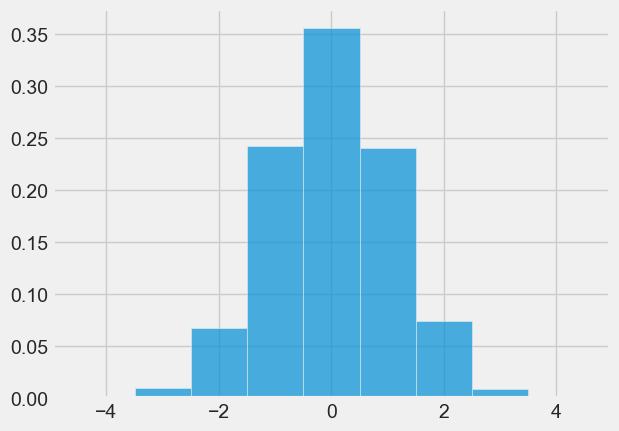

In [85]:
plot_distribution(differences)

### Question 1f


In [86]:
empirical_p = np.count_nonzero(np.abs(differences) >= np.abs(observed_difference)) / repetitions
empirical_p

0.0026

In [87]:
grader.check("q1f")

q1f results: All test cases passed!

### Question 1g
根据你计算的经验p值，我们是拒绝还是不拒绝原假设？使用问题1c中提出的0.01或1%的p值截止值。

0.0026<0.01，拒绝原假设H0，认为在1%的显著性水平下，有统计学证据认为母亲是否吸烟会影响婴儿出生体重。

In [88]:
grader.export(run_tests=True)

D:\Anaconda\envs\data100\lib\site-packages\otter\check\notebook.py:494: UserWarning: Could not locate a PDF to include
  warnings.warn("Could not locate a PDF to include")
